# Machine Learning Course - Setup Instructions

## Environment Setup (ensure you have done it before running the notebook)

### 1. Create a Virtual Environment
First, navigate to the folder where you cloned this repository, then create the virtual environment:
```bash
cd /path/to/modelizacion  # Navigate to the repository folder
python3 -m venv .modelizacion_env
```

The virtual environment `.modelizacion_env` will be created in the same folder as this notebook and `requirements.txt`.

### 2. Activate the Virtual Environment
```bash
source .modelizacion_env/bin/activate
```

### 3. Install Requirements
```bash
pip install -r requirements.txt
```

### 4. Add Environment to Jupyter Kernels
To use this environment in Jupyter, run:
```bash
python -m ipykernel install --user --name=modelizacion --display-name="Python (ML Course)"
```

### 5. Select the Kernel
In Jupyter/VS Code, select the kernel "Python (ML Course)" from the kernel picker (top right).

---

## Notation Convention

### Training Data
- $N$: number of training samples
- $x_n, n=1,\ldots,N$: training input samples, where $x \in \mathbb{R}^d$
- $y_n, n=1,\ldots,N$: training targets/labels
- $d$: input dimension
- $d'$: output dimension

### Features and Model
- $\phi_j(x), j=0,1,\ldots,m-1$: feature functions
- $\Phi$: feature matrix with elements $\Phi_{nj} = \phi_j(x_n)$
- $m$: number of features
- $w$: parameter vector/matrix
- $f(x, w)$: model function

### Classification
- $k$: index for output components in categorical classification (number of classes)
- $K$: total number of classes

### Loss and Predictions
- $L$: loss function
- $\hat{y}$: predictions

In [1]:
# Import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

# Deep learning libraries
import tensorflow as tf

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"TensorFlow version: {tf.__version__}")

Libraries imported successfully!
NumPy version: 2.4.3
TensorFlow version: 2.21.0


---
## 1. Linear Regression

Given training data $(x_n, y_n),$ $n=1,\ldots,N$, we want to find parameters $w = (w_0, w_1,\ldots,w_{m-1})^T \in \mathbb{R}^m$ such that the model function

$$f(x, w) = w^T \phi(x),$$

where $\phi(x) = (\phi_0(x), \ldots, \phi_{m-1}(x))^T$ are fixed features, minimises the squared loss

$$L(w) = \frac{1}{N}\sum_{n=1}^N (y_n - f(x_n, w))^2$$
The loss function is can also be rewritten as

$$L(w) = \frac{1}{N}||Y - \Phi w||^2,$$

where $\Phi \in \mathbb{R}^{N \times m}$ is the feature matrix with each row $n$ containing $\phi(x_n) = (\phi_0(x_n), \ldots, \phi_{m-1}(x_n))$, and $Y = (y_1,\ldots,y_N)^T \in \mathbb{R}^{N}$. 

The closed-form solution is:

$$w^* = (\Phi^T\Phi)^{-1}\Phi^T Y$$

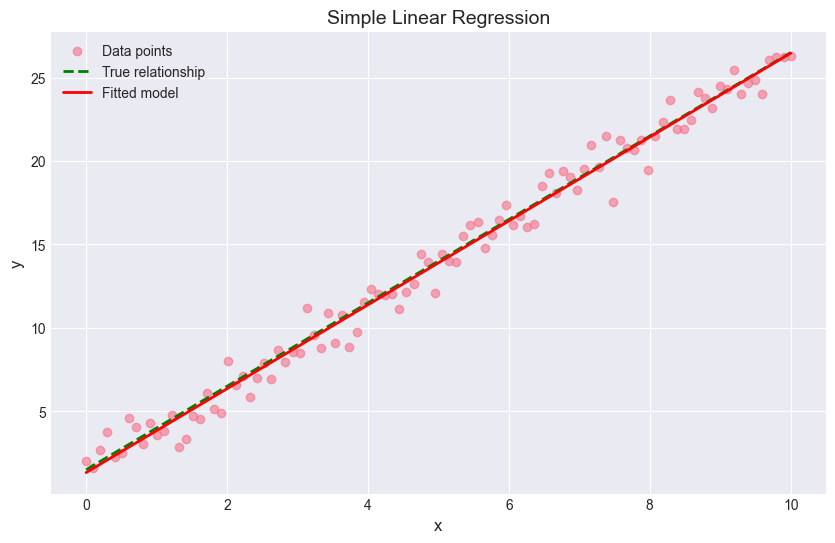

True parameters: w₀ = 1.5, w₁ = 2.5
Fitted parameters: w₀ = 1.327, w₁ = 2.514
MSE: 0.815


In [2]:
# Generate synthetic data
np.random.seed(42)  # For reproducibility
X_simple = np.linspace(0, 10, 100)  # 100 evenly spaced points from 0 to 10
y_true = 2.5 * X_simple + 1.5  # True relationship: y = 2.5x + 1.5
y_noisy = y_true + np.random.normal(0, 1, 100)  # Add Gaussian noise (mean=0, std=2)

# Fit linear regression
X_matrix = X_simple.reshape(-1, 1)  # sklearn requires 2D array: (n_samples, n_features)
model = LinearRegression()  # Create model object
model.fit(X_matrix, y_noisy)  # Learn parameters w₀ and w₁ from data

# Make predictions using learned model
y_pred = model.predict(X_matrix)

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X_simple, y_noisy, alpha=0.6, label='Data points')
plt.plot(X_simple, y_true, 'g--', linewidth=2, label='True relationship')
plt.plot(X_simple, y_pred, 'r-', linewidth=2, label='Fitted model')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Simple Linear Regression', fontsize=14)
plt.legend()
plt.show()

print(f"True parameters: w₀ = 1.5, w₁ = 2.5")
print(f"Fitted parameters: w₀ = {model.intercept_:.3f}, w₁ = {model.coef_[0]:.3f}")
print(f"MSE: {mean_squared_error(y_noisy, y_pred):.3f}")

### Real-World Example: California Housing Prices

Now let's apply linear regression to real data: predicting median house values in California based on location, population, and income.

In [3]:
# Load the REAL California Housing dataset
from sklearn.datasets import fetch_california_housing

housing_data = fetch_california_housing()  # Download/load dataset from sklearn

# Print official description (stored in housing_data.DESCR)
print(housing_data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [4]:
X_housing = housing_data.data  # Feature matrix: shape (20640, 8)
y_housing = housing_data.target  # Target vector: median house value in $100,000s
feature_names_housing = housing_data.feature_names  # Names of the 8 features

print("="*70)
print("\n" + "="*70)
print(f"Data structure:")
print(f"  • {X_housing.shape[0]:,} samples × {X_housing.shape[1]} features")
print(f"  • Features: {', '.join(feature_names_housing)}")
print(f"  • Target range: ${y_housing.min()*100:.0f}k - ${y_housing.max()*100:.0f}k")
print(f"\nData types:")
print(f"  • X_housing: {type(X_housing).__name__} with dtype {X_housing.dtype}")
print(f"  • y_housing: {type(y_housing).__name__} with dtype {y_housing.dtype}")
print("="*70)


Data structure:
  • 20,640 samples × 8 features
  • Features: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
  • Target range: $15k - $500k

Data types:
  • X_housing: ndarray with dtype float64
  • y_housing: ndarray with dtype float64


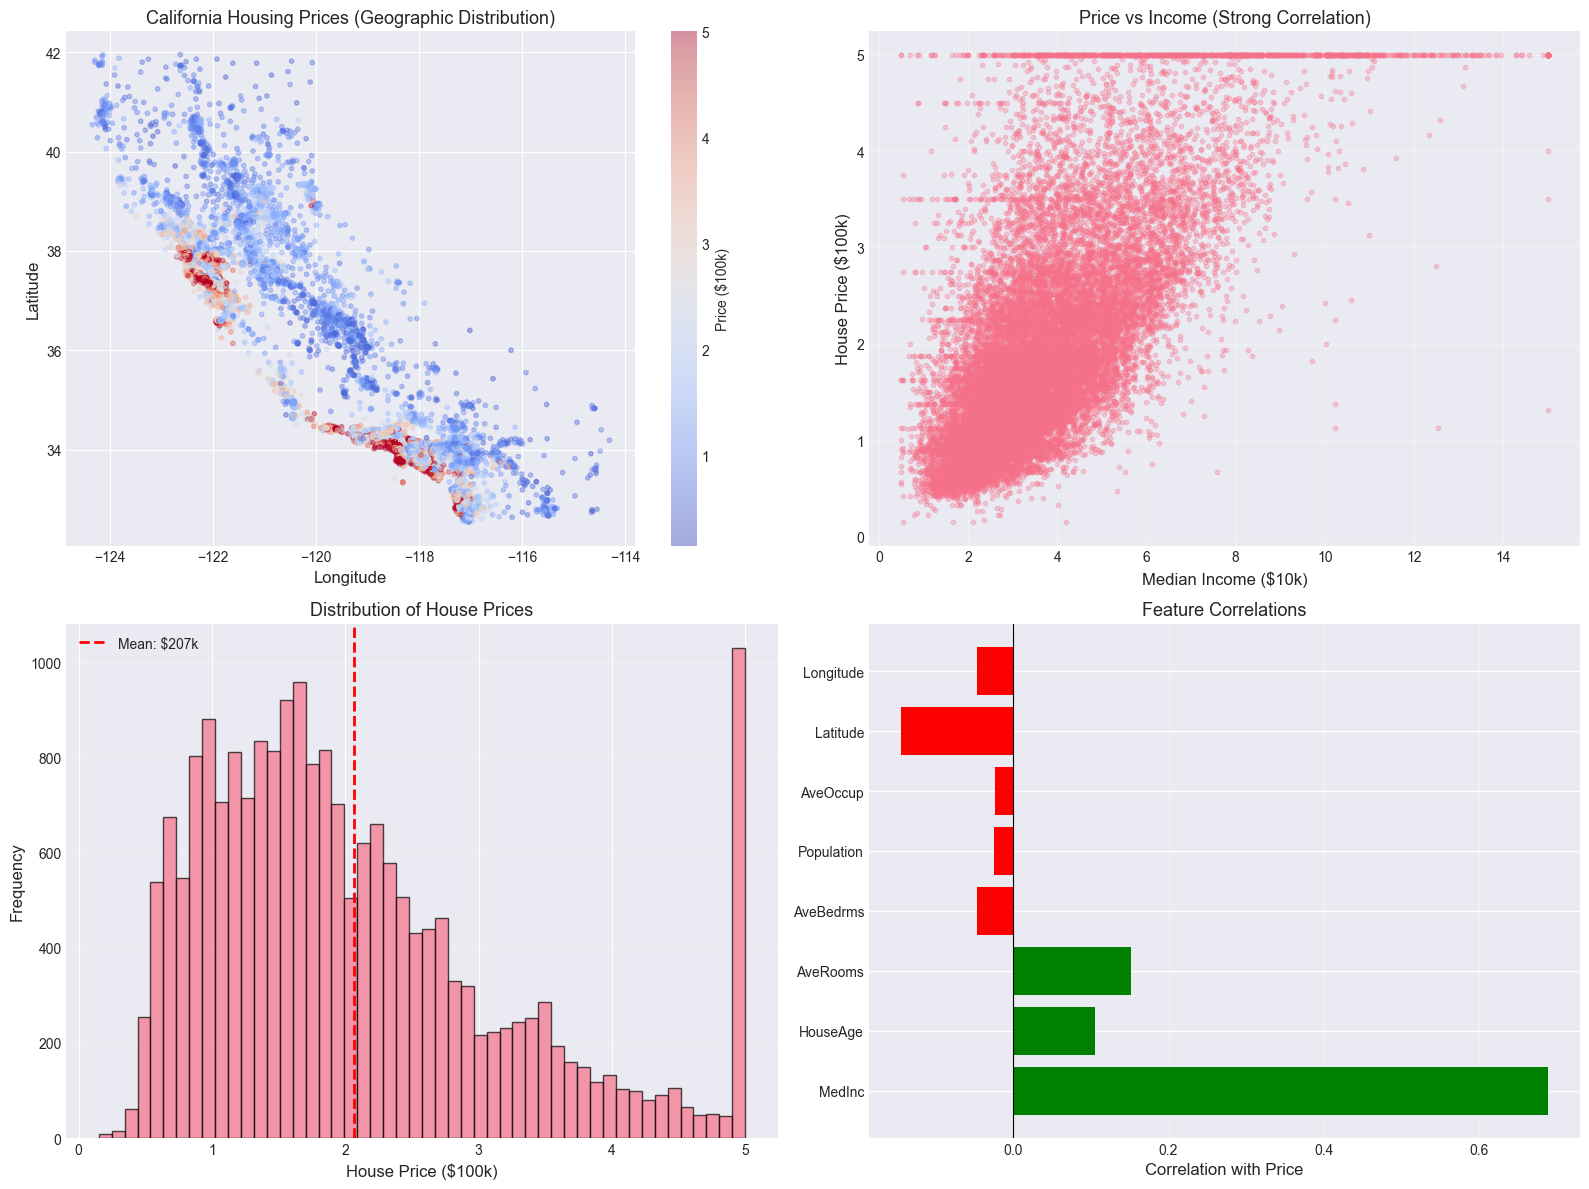


Key Observations:
• You can see the shape of California in the geographic plot!
• Coastal areas (left side) tend to be more expensive
• Median income has strongest correlation: 0.688
• Most prices are capped at $500k (data collection limit)


In [5]:
# Visualize the dataset - understand what we're working with
fig, axes = plt.subplots(2, 2, figsize=(16, 12))  # Create 2×2 grid of plots

# Plot 1: Geographic scatter plot (Latitude vs Longitude colored by price)
# X_housing[:, 7] is Longitude, X_housing[:, 6] is Latitude
scatter = axes[0, 0].scatter(X_housing[:, 7], X_housing[:, 6],
                            c=y_housing, cmap='coolwarm',  # Color by price
                            alpha=0.4, s=10)  # Semi-transparent, small dots
axes[0, 0].set_xlabel('Longitude', fontsize=12)
axes[0, 0].set_ylabel('Latitude', fontsize=12)
axes[0, 0].set_title('California Housing Prices (Geographic Distribution)', fontsize=13)
plt.colorbar(scatter, ax=axes[0, 0], label='Price ($100k)')

# Plot 2: Price vs Median Income (strongest predictor)
axes[0, 1].scatter(X_housing[:, 0], y_housing, alpha=0.3, s=10)
axes[0, 1].set_xlabel('Median Income ($10k)', fontsize=12)
axes[0, 1].set_ylabel('House Price ($100k)', fontsize=12)
axes[0, 1].set_title('Price vs Income (Strong Correlation)', fontsize=13)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Price distribution
axes[1, 0].hist(y_housing, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('House Price ($100k)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Distribution of House Prices', fontsize=13)
axes[1, 0].axvline(y_housing.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${y_housing.mean()*100:.0f}k')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Correlation ranges from -1 (perfect negative) to +1 (perfect positive)
correlations = [np.corrcoef(X_housing[:, i], y_housing)[0, 1] for i in range(8)]
colors_corr = ['green' if c > 0 else 'red' for c in correlations]  # Visual cue
axes[1, 1].barh(feature_names_housing, correlations, color=colors_corr)
axes[1, 1].set_xlabel('Correlation with Price', fontsize=12)
axes[1, 1].set_title('Feature Correlations', fontsize=13)
axes[1, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("• You can see the shape of California in the geographic plot!")
print("• Coastal areas (left side) tend to be more expensive")
print(f"• Median income has strongest correlation: {correlations[0]:.3f}")
print("• Most prices are capped at $500k (data collection limit)")

In [6]:
# Train linear regression model
print("="*70)
print("Training Linear Regression Model")
print("="*70)

# Split into train and test sets (80/20 split)
# Never train and test on the same data!
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)
print(f"Training samples: {X_train_h.shape[0]:,}")
print(f"Test samples:     {X_test_h.shape[0]:,}")

# Standardize features (CRUCIAL when features have different scales!)
# Why? Income ranges from 0-15, but Latitude ranges from 32-42
# Formula: z = (x - μ) / σ  (subtract mean, divide by std)
scaler = StandardScaler()
X_train_h_scaled = scaler.fit_transform(X_train_h)  # Fit on train, transform train
X_test_h_scaled = scaler.transform(X_test_h)  # Only transform test (use train statistics!)

print("\nFeature scaling applied ✓")
# Fit the model using Normal Equation: w* = (X^T X)^(-1) X^T y

housing_model = LinearRegression()
housing_model.fit(X_train_h_scaled, y_train_h)  # Finds optimal w_0, w_1, ..., w_8

print("\nModel trained successfully!")
print(f"Learned {len(housing_model.coef_)} coefficients + 1 intercept")

Training Linear Regression Model
Training samples: 16,512
Test samples:     4,128

Feature scaling applied ✓

Model trained successfully!
Learned 8 coefficients + 1 intercept


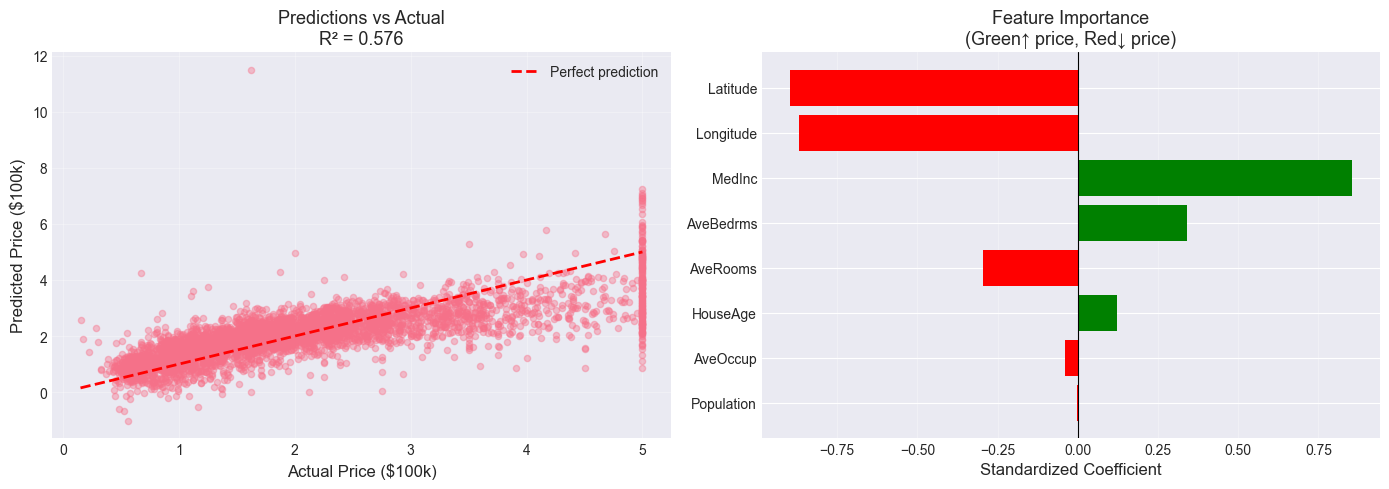

In [7]:
# Evaluate the model on test set (unseen data)
y_pred_train_h = housing_model.predict(X_train_h_scaled)
y_pred_test_h = housing_model.predict(X_test_h_scaled)

# R² score: proportion of variance explained (closer to 1 is better)
test_r2 = housing_model.score(X_test_h_scaled, y_test_h)
# MSE: mean squared error (lower is better)
test_mse_h = mean_squared_error(y_test_h, y_pred_test_h)

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual
axes[0].scatter(y_test_h, y_pred_test_h, alpha=0.4, s=20)
axes[0].plot([y_test_h.min(), y_test_h.max()],
             [y_test_h.min(), y_test_h.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($100k)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($100k)', fontsize=12)
axes[0].set_title(f'Predictions vs Actual\nR² = {test_r2:.3f}', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Feature importance (learned coefficients)
# Larger |coefficient| → stronger influence on price
coefficients = housing_model.coef_  # The learned weights w_1, ..., w_8
sorted_idx = np.argsort(np.abs(coefficients))  # Sort by absolute value
colors = ['green' if coefficients[i] > 0 else 'red' for i in sorted_idx]

axes[1].barh(np.array(feature_names_housing)[sorted_idx],
             coefficients[sorted_idx], color=colors)
axes[1].set_xlabel('Standardized Coefficient', fontsize=12)
axes[1].set_title('Feature Importance\n(Green↑ price, Red↓ price)', fontsize=13)
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [8]:
print("="*70)
print("Model Performance")
print("="*70)
print(f"R² Score:  {test_r2:.4f} (explains {test_r2*100:.1f}% of price variance)")
print(f"RMSE:      ${np.sqrt(test_mse_h)*100:.0f}k (average prediction error)")
print(f"\nMost Important Features:")
top_3_idx = np.argsort(np.abs(coefficients))[-3:][::-1]
for idx in top_3_idx:
    effect = "increases" if coefficients[idx] > 0 else "decreases"
    print(f"  {feature_names_housing[idx]:12s}: {effect} price (coef = {coefficients[idx]:+.3f})")
print("\n✓ Median income is the strongest predictor!")

Model Performance
R² Score:  0.5758 (explains 57.6% of price variance)
RMSE:      $75k (average prediction error)

Most Important Features:
  Latitude    : decreases price (coef = -0.897)
  Longitude   : decreases price (coef = -0.870)
  MedInc      : increases price (coef = +0.854)

✓ Median income is the strongest predictor!


### Polynomial Features: Approximating sin(x)

Key Insight: Linear regression is linear in parameters, not features! We can use polynomial features:

$$f(x, w) = w_0 + w_1 x + w_2 x^2 + \cdots + w_{m-1} x^{m-1}$$

In this case, 

$$\phi(x) = (\phi_0(x),\phi_1(x),\ldots,\phi_{m-1}(x)) = (1, x, x^2,\ldots,x^{m-1})$$

Let's approximate $\sin(x)$ using polynomial features.

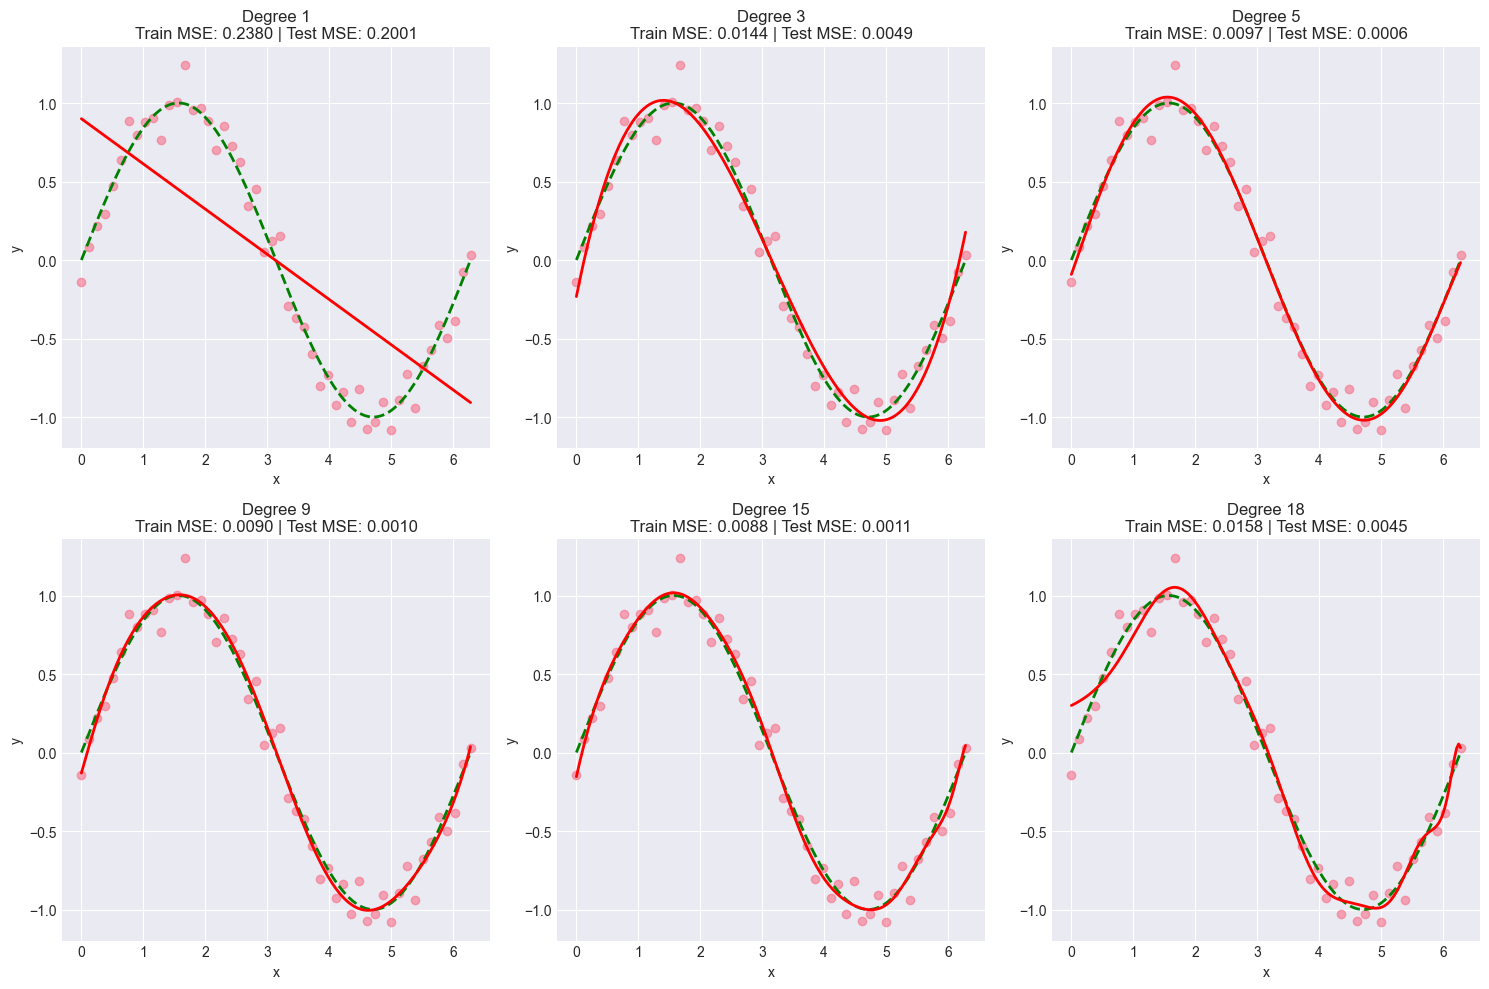

In [9]:
# Generate data from sin(x)
X_sin = np.linspace(0, 2*np.pi, 50).reshape(-1, 1)
y_sin = np.sin(X_sin).ravel() + np.random.normal(0, 0.1, 50)

# Test different polynomial degrees
degrees = [1, 3, 5, 9, 15, 18]
X_test = np.linspace(0, 2*np.pi, 200).reshape(-1, 1)
y_test_true = np.sin(X_test).ravel()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, degree in enumerate(degrees):
    # Create polynomial features: builds design matrix Φ where each row contains φ(x_n)
    # For degree m: φ(x) = (1, x, x², ..., x^m)
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_sin)  # Φ_train: N_train × (m+1)
    X_test_poly = poly.transform(X_test)  # Φ_test: N_test × (m+1)

    # Fit model using normal equation (exact solution)
    # Note: PolynomialFeatures already includes bias, so fit_intercept=False
    model = LinearRegression(fit_intercept=False)
    model.fit(X_poly, y_sin)
    y_pred = model.predict(X_test_poly)

    # Calculate training MSE (on noisy training data)
    y_train_pred = model.predict(X_poly)
    train_mse = np.mean((y_train_pred - y_sin)**2)

    # Calculate test MSE (comparing to true sin(x) - the underlying function)
    test_mse = np.mean((y_pred - y_test_true)**2)

    # Plot
    axes[idx].scatter(X_sin, y_sin, alpha=0.6, label='Data')
    axes[idx].plot(X_test, y_test_true, 'g--', linewidth=2, label='True sin(x)')
    axes[idx].plot(X_test, y_pred, 'r-', linewidth=2, label=f'Degree {degree}')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    axes[idx].set_title(f'Degree {degree}\nTrain MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}')
plt.tight_layout()
plt.show()

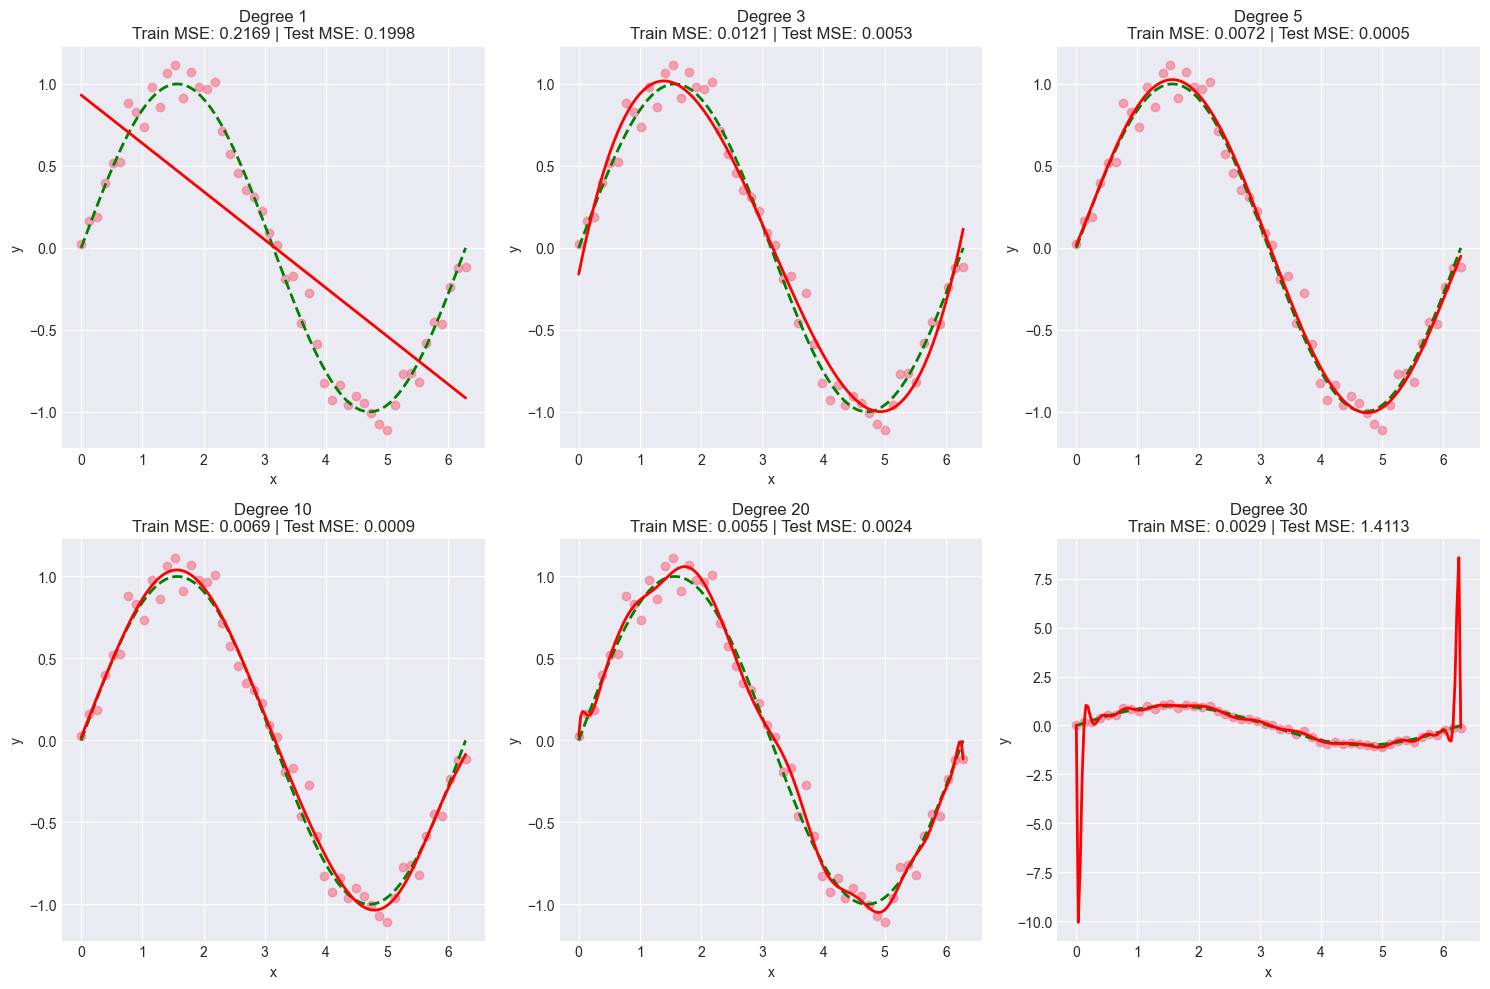

In [10]:
# Same example as above but normalising the data
# Generate data from sin(x)
X_sin = np.linspace(0, 2*np.pi, 50).reshape(-1, 1)
y_sin = np.sin(X_sin).ravel() + np.random.normal(0, 0.1, 50)

# Normalize X to [-1, 1] for numerical stability in high-degree polynomials
X_min, X_max = X_sin.min(), X_sin.max()
X_sin_norm = 2 * (X_sin - X_min) / (X_max - X_min) - 1

# Test different polynomial degrees
degrees = [1, 3, 5, 10, 20, 30]
X_test = np.linspace(0, 2*np.pi, 200).reshape(-1, 1)
X_test_norm = 2 * (X_test - X_min) / (X_max - X_min) - 1
y_test_true = np.sin(X_test).ravel()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, degree in enumerate(degrees):
    # Create polynomial features: builds design matrix Φ where each row contains φ(x_n)
    # For degree m: φ(x) = (1, x, x², ..., x^m)
    # Note: Using normalized x ∈ [-1,1] for numerical stability
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_sin_norm)  # Φ_train: N_train × (m+1)
    X_test_poly = poly.transform(X_test_norm)  # Φ_test: N_test × (m+1)

    # Fit model using normal equation (exact solution)
    # Note: PolynomialFeatures already includes bias, so fit_intercept=False
    model = LinearRegression(fit_intercept=False)
    model.fit(X_poly, y_sin)
    y_pred = model.predict(X_test_poly)

    # Calculate training MSE (on noisy training data)
    y_train_pred = model.predict(X_poly)
    train_mse = np.mean((y_train_pred - y_sin)**2)

    # Calculate test MSE (comparing to true sin(x) - the underlying function)
    test_mse = np.mean((y_pred - y_test_true)**2)

    # Plot
    axes[idx].scatter(X_sin, y_sin, alpha=0.6, label='Data')
    axes[idx].plot(X_test, y_test_true, 'g--', linewidth=2, label='True sin(x)')
    axes[idx].plot(X_test, y_pred, 'r-', linewidth=2, label=f'Degree {degree}')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    axes[idx].set_title(f'Degree {degree}\nTrain MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}')
plt.tight_layout()
plt.show()

### Alternative: Gaussian (RBF) Features

Instead of polynomials, we can use Gaussian basis functions (also called Radial Basis Functions):

$$\phi_i(x) = \exp\left(-\frac{(x - \mu_i)^2}{2\sigma^2}\right)$$

where $\mu_i$ are center points spread across the input space and $\sigma$ controls the width.

Why Gaussian features?
- Better suited for periodic/smooth functions like sin(x)
- More localized influence (each feature affects a local region)
- No numerical stability issues with high dimensions

In [12]:
# Create Gaussian/RBF features manually
def gaussian_features(X, centers, sigma=0.3):
    """
    Create Gaussian RBF features: φ_i(x) = exp(-(x - μ_i)²/(2σ²))

    Args:
    - X: input data (N × 1)
    - centers: center points for Gaussian basis functions (m,)
    - sigma: width parameter

    Returns:
    - Φ: design matrix with Gaussian features (N × (m+1)) including bias
    """
    N = X.shape[0]
    m = len(centers)
    Phi = np.zeros((N, m + 1))
    Phi[:, 0] = 1  # Bias term

    for i, mu in enumerate(centers):
        Phi[:, i+1] = np.exp(-((X.ravel() - mu)**2) / (2 * sigma**2))

    return Phi

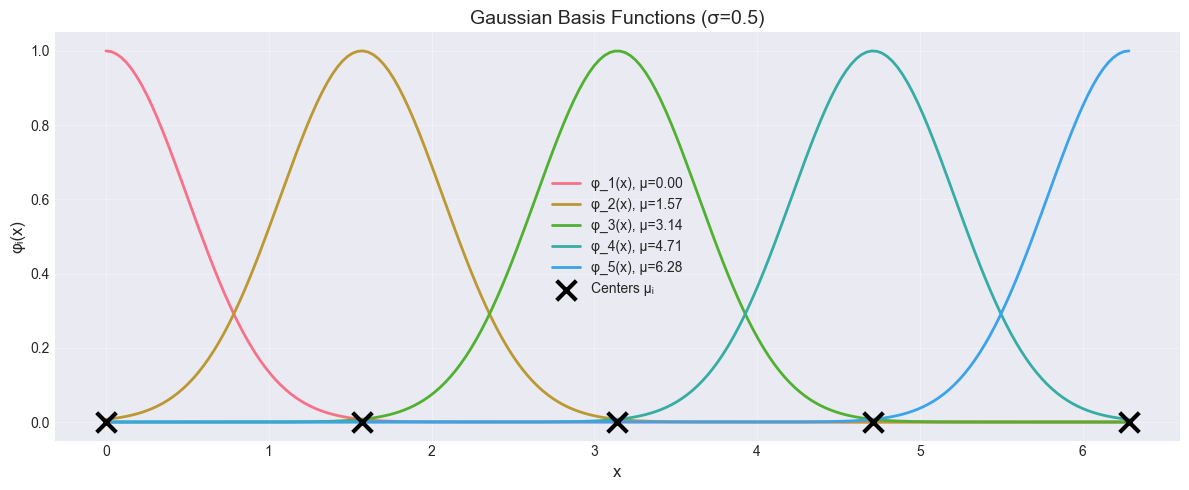

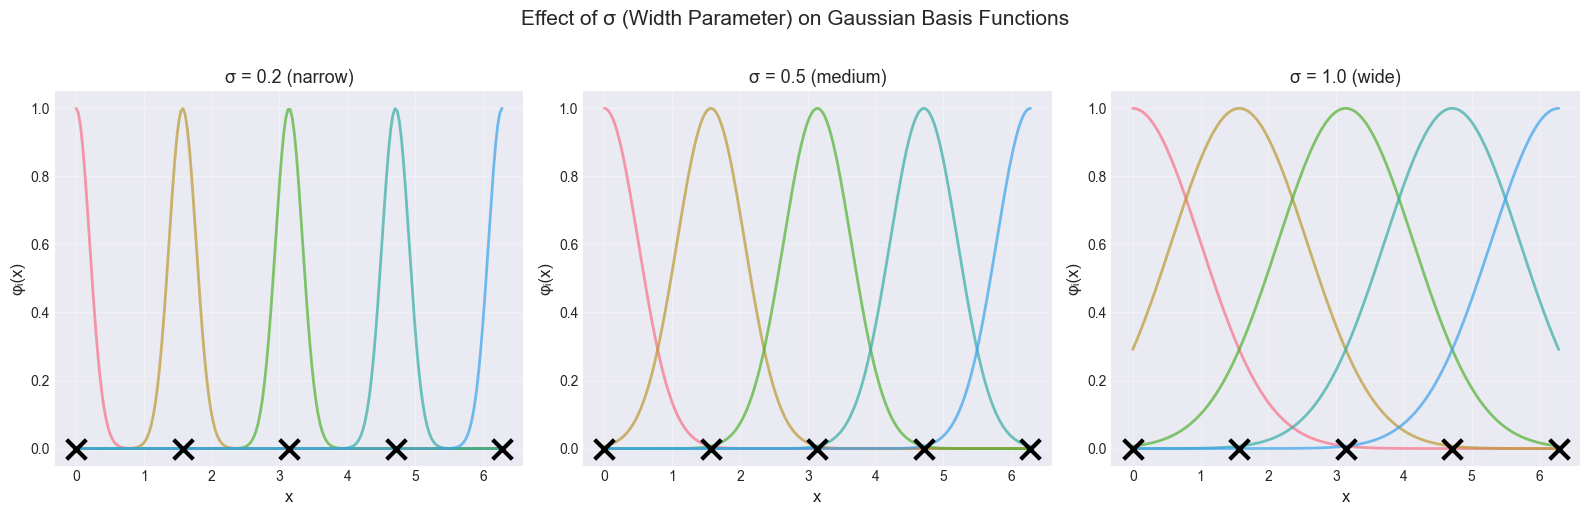

In [13]:
# Visualize what Gaussian features look like
x_demo = np.linspace(0, 2*np.pi, 200).reshape(-1, 1)
centers_demo = np.linspace(0, 2*np.pi, 5)
sigma_demo = 0.5

plt.figure(figsize=(12, 5))

# Plot individual Gaussian basis functions
for i, mu in enumerate(centers_demo):
    phi_i = np.exp(-((x_demo.ravel() - mu)**2) / (2 * sigma_demo**2))
    plt.plot(x_demo, phi_i, label=f'φ_{i+1}(x), μ={mu:.2f}', linewidth=2)

plt.scatter(centers_demo, np.zeros_like(centers_demo), marker='x', s=200, 
            c='black', zorder=5, linewidths=3, label='Centers μᵢ')
plt.xlabel('x', fontsize=12)
plt.ylabel('φᵢ(x)', fontsize=12)
plt.title(f'Gaussian Basis Functions (σ={sigma_demo})', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compare different sigma values
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sigma_values = [0.2, 0.5, 1.0]
centers_compare = np.linspace(0, 2*np.pi, 5)

for ax, sigma in zip(axes, sigma_values):
    for i, mu in enumerate(centers_compare):
        phi_i = np.exp(-((x_demo.ravel() - mu)**2) / (2 * sigma**2))
        ax.plot(x_demo, phi_i, linewidth=2, alpha=0.7)
    
    ax.scatter(centers_compare, np.zeros_like(centers_compare), marker='x', 
               s=200, c='black', zorder=5, linewidths=3)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('φᵢ(x)', fontsize=12)
    ax.set_title(f'σ = {sigma} ({"narrow" if sigma < 0.4 else "medium" if sigma < 0.8 else "wide"})', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

plt.suptitle('Effect of σ (Width Parameter) on Gaussian Basis Functions', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

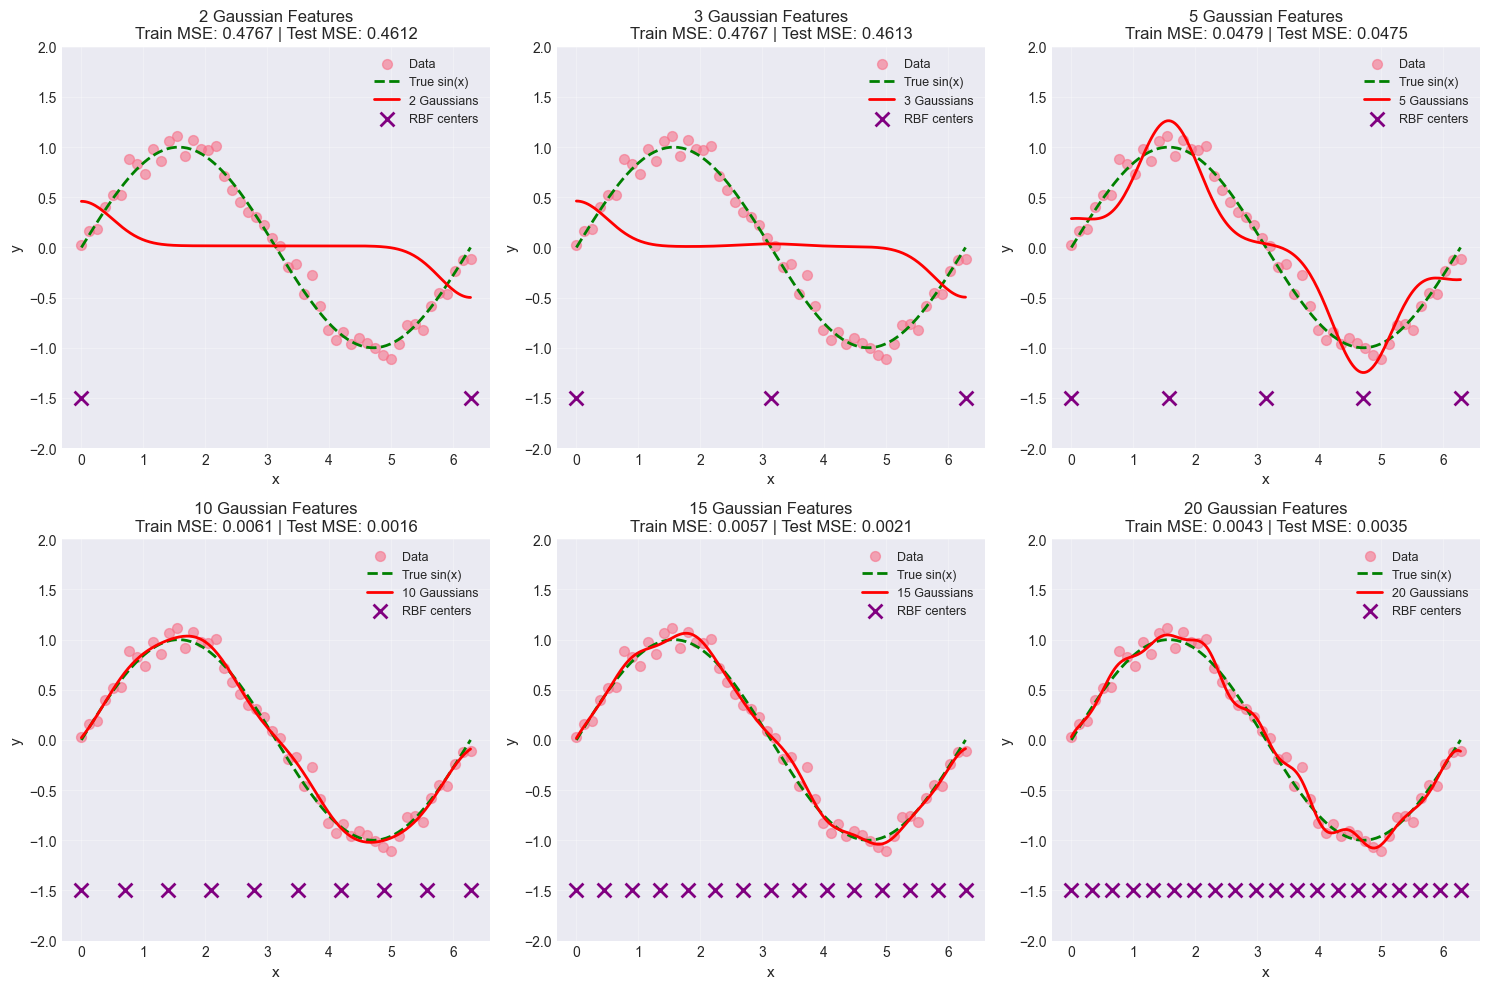

In [14]:
# Test with different numbers of Gaussian basis functions
n_centers_list = [2, 3, 5, 10, 15, 20]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, n_centers in enumerate(n_centers_list):
    # Place centers uniformly across [0, 2π]
    centers = np.linspace(0, 2*np.pi, n_centers)

    # Create Gaussian features
    Phi_train = gaussian_features(X_sin, centers, sigma=0.5)
    Phi_test = gaussian_features(X_test, centers, sigma=0.5)

    # Fit using normal equation (exact solution)
    model = LinearRegression(fit_intercept=False)
    model.fit(Phi_train, y_sin)
    y_pred = model.predict(Phi_test)

    # Calculate errors
    y_train_pred = model.predict(Phi_train)
    train_mse = np.mean((y_train_pred - y_sin)**2)
    test_mse = np.mean((y_pred - y_test_true)**2)

    # Plot
    axes[idx].scatter(X_sin, y_sin, alpha=0.6, label='Data', s=50)
    axes[idx].plot(X_test, y_test_true, 'g--', linewidth=2, label='True sin(x)')
    axes[idx].plot(X_test, y_pred, 'r-', linewidth=2, label=f'{n_centers} Gaussians')

    # Show Gaussian centers
    axes[idx].scatter(centers, np.zeros_like(centers) - 1.5, marker='x', s=100,
                     c='purple', label='RBF centers', linewidths=2)

    axes[idx].set_xlabel('x', fontsize=11)
    axes[idx].set_ylabel('y', fontsize=11)
    axes[idx].set_title(f'{n_centers} Gaussian Features\nTrain MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}',
                       fontsize=12)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(-2, 2)

plt.tight_layout()
plt.show()

---
## 2. The Overfitting Crisis

### Demonstrating Overfitting

Key Problem: Models that are too complex memorize training data but fail to generalize.

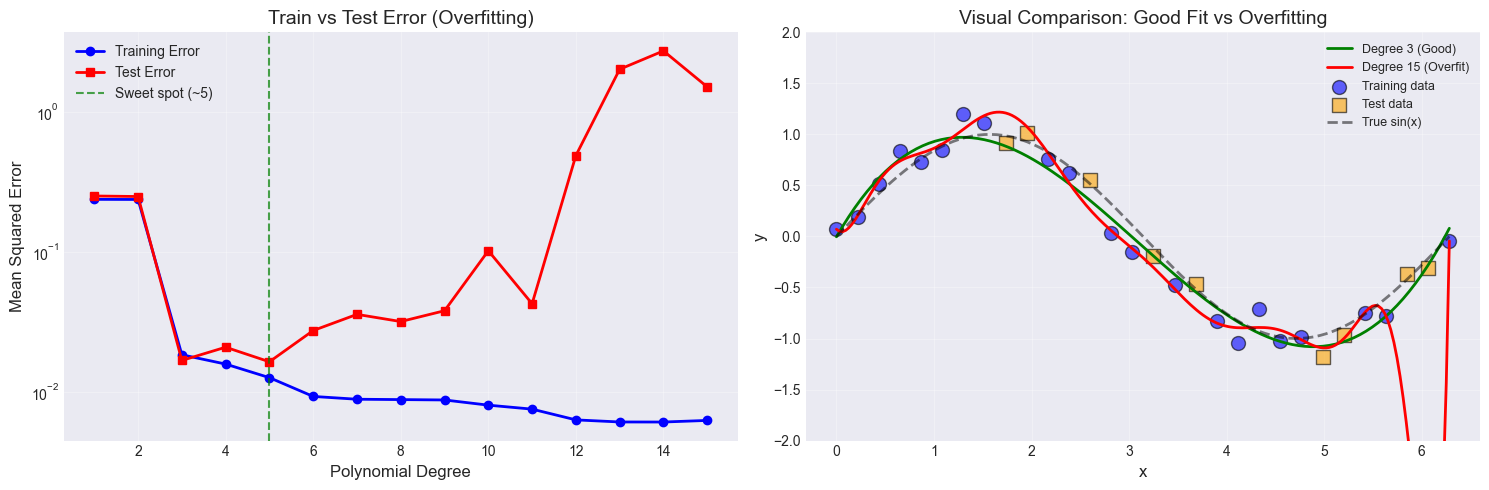

In [15]:
# Generate data with train/test split
np.random.seed(42)
X_full = np.linspace(0, 2*np.pi, 30).reshape(-1, 1)
y_full = np.sin(X_full).ravel() + np.random.normal(0, 0.15, 30)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.3, random_state=42)

# Sort for visualization
train_idx = np.argsort(X_train.ravel())
test_idx = np.argsort(X_test.ravel())

# Test many polynomial degrees
degrees = range(1, 16)
train_errors = []
test_errors = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_mse = mean_squared_error(y_train, model.predict(X_train_poly))
    test_mse = mean_squared_error(y_test, model.predict(X_test_poly))

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Plot learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: Train vs Test Error
ax1.plot(degrees, train_errors, 'b-o', label='Training Error', linewidth=2)
ax1.plot(degrees, test_errors, 'r-s', label='Test Error', linewidth=2)
ax1.axvline(x=5, color='g', linestyle='--', alpha=0.7, label='Sweet spot (~5)')
ax1.set_xlabel('Polynomial Degree', fontsize=12)
ax1.set_ylabel('Mean Squared Error', fontsize=12)
ax1.set_title('Train vs Test Error (Overfitting)', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Right plot: Show overfitting visually
X_plot = np.linspace(0, 2*np.pi, 200).reshape(-1, 1)
y_plot_true = np.sin(X_plot).ravel()

for degree, color, label in [(3, 'green', 'Degree 3 (Good)'),
                              (15, 'red', 'Degree 15 (Overfit)')]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_plot_poly = poly.transform(X_plot)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_plot_poly)

    ax2.plot(X_plot, y_pred, color=color, linewidth=2, label=label)

ax2.scatter(X_train, y_train, c='blue', s=100, alpha=0.6, edgecolors='black', label='Training data')
ax2.scatter(X_test, y_test, c='orange', s=100, alpha=0.6, edgecolors='black', marker='s', label='Test data')
ax2.plot(X_plot, y_plot_true, 'k--', linewidth=2, alpha=0.5, label='True sin(x)')
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_title('Visual Comparison: Good Fit vs Overfitting', fontsize=14)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-2, 2)

plt.tight_layout()
plt.show()

---
## 3. Regularization to the Rescue

### L² Regularization (Ridge Regression)

Add a penalty term to prevent large weights:

$$L_{\text{ridge}}(w) = \frac{1}{N}||Y - \Phi w||^2 + \lambda||w||^2$$

The exact solution becomes:

$$w^* = (\Phi^T \Phi + \lambda I)^{-1} \Phi^T y$$

/Users/macbookpro/ml/modelizacion/modelisation_practice/.modelizacion_env/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.936325970565432e-24.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/macbookpro/ml/modelizacion/modelisation_practice/.modelizacion_env/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.025368730209423e-24.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


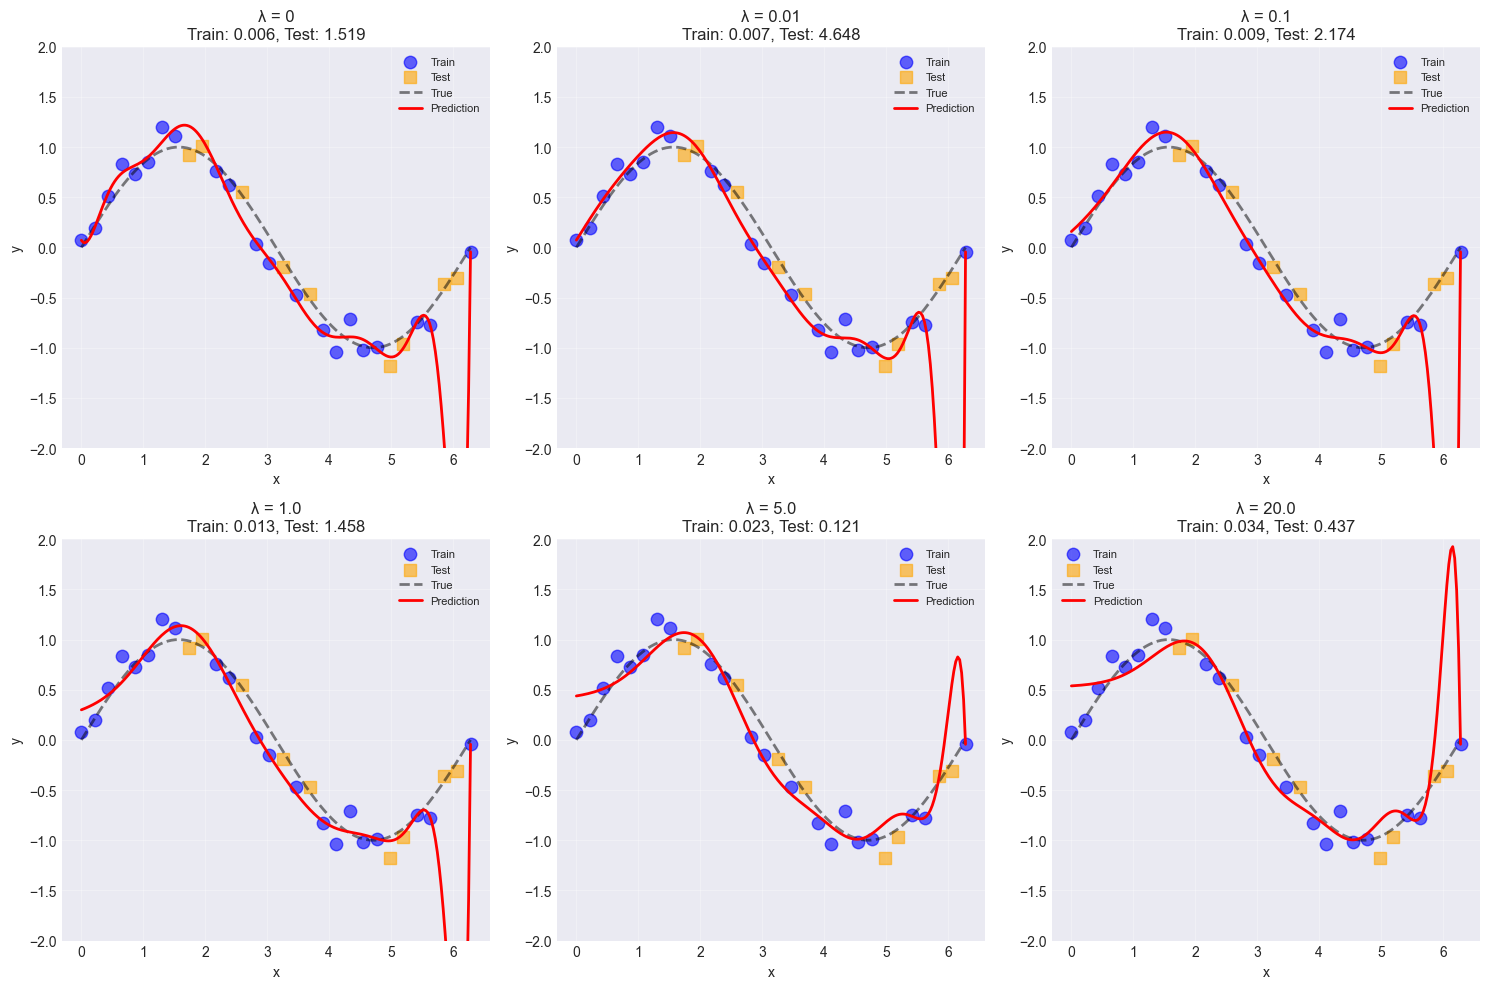

In [16]:
# High-degree polynomial with and without regularization
degree = 15
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_plot_poly = poly.transform(X_plot)

# Test different regularization strengths
alphas = [0, 0.01, 0.1, 1.0, 5.0, 20.0]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

weights_history = []

for idx, alpha in enumerate(alphas):
    if alpha == 0:
        model = LinearRegression()
    else:
        model = Ridge(alpha=alpha)

    model.fit(X_train_poly, y_train)
    y_pred_train = model.predict(X_train_poly)
    y_pred_test = model.predict(X_test_poly)
    y_pred_plot = model.predict(X_plot_poly)

    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)

    # Store coefficients
    weights_history.append(model.coef_ if hasattr(model, 'coef_') else None)

    # Plot
    axes[idx].scatter(X_train, y_train, c='blue', s=80, alpha=0.6, label='Train')
    axes[idx].scatter(X_test, y_test, c='orange', s=80, alpha=0.6, marker='s', label='Test')
    axes[idx].plot(X_plot, y_plot_true, 'k--', linewidth=2, alpha=0.5, label='True')
    axes[idx].plot(X_plot, y_pred_plot, 'r-', linewidth=2, label='Prediction')
    axes[idx].set_ylim(-2, 2)
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    axes[idx].set_title(f'λ = {alpha}\nTrain: {train_mse:.3f}, Test: {test_mse:.3f}')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Coefficient Shrinkage

Let's visualize how regularization shrinks the coefficients.

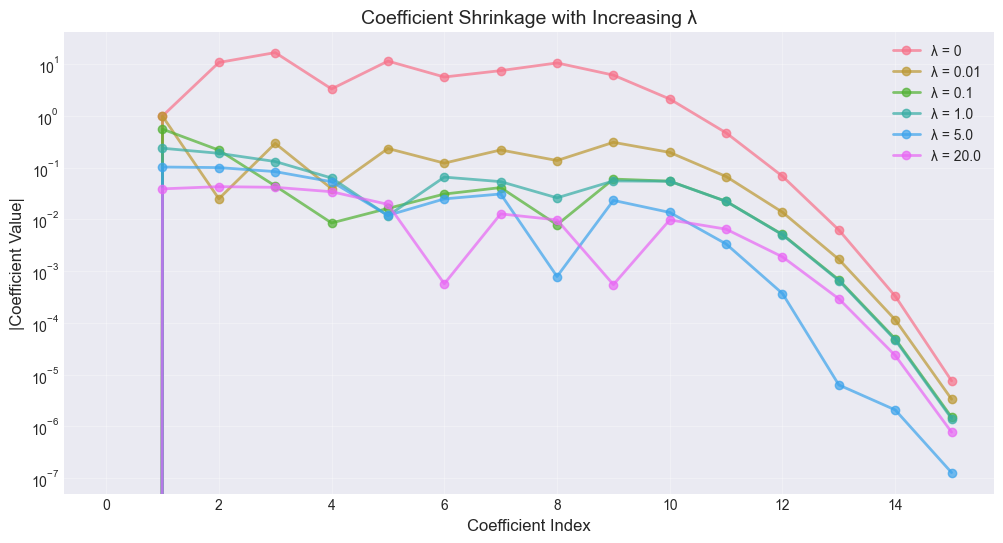

In [17]:
# Visualize coefficient magnitudes
plt.figure(figsize=(12, 6))

for idx, (alpha, weights) in enumerate(zip(alphas, weights_history)):
    if weights is not None:
        plt.plot(range(len(weights)), np.abs(weights), 'o-',
                label=f'λ = {alpha}', alpha=0.7, linewidth=2)

plt.xlabel('Coefficient Index', fontsize=12)
plt.ylabel('|Coefficient Value|', fontsize=12)
plt.title('Coefficient Shrinkage with Increasing λ', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

### Cross-Validation for Hyperparameter Selection

How do we choose the best $\lambda$? Use cross-validation!

Cross-validation dataset: 80 training points, 11 features
This gives ~16 points per CV fold (much more stable!)



/Users/macbookpro/ml/modelizacion/modelisation_practice/.modelizacion_env/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.688228831680092e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/macbookpro/ml/modelizacion/modelisation_practice/.modelizacion_env/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.4559301295898673e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/macbookpro/ml/modelizacion/modelisation_practice/.modelizacion_env/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.9166724970940346e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/macbookpro/ml/modelizacion/modelisation_practice/.modelizacion_env/lib/python3.11/site-packages/s

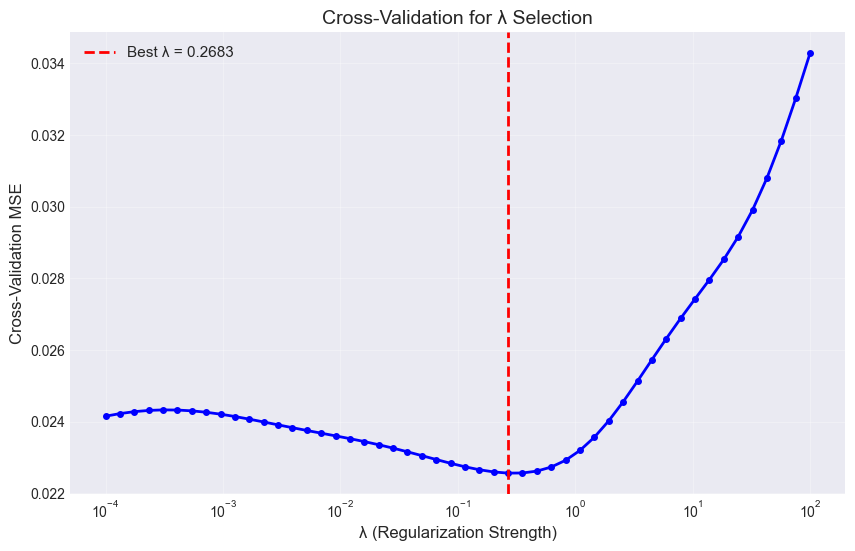

Best λ = 0.2683
Cross-validation MSE at best λ = 0.0226
Test MSE with best λ = 0.0158


/Users/macbookpro/ml/modelizacion/modelisation_practice/.modelizacion_env/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.530148407377162e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [18]:
# Generate a larger dataset for more stable cross-validation
# (The previous dataset was too small: only 21 points with 16 features!)
np.random.seed(42)
X_cv = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)
y_cv = np.sin(X_cv).ravel() + np.random.normal(0, 0.15, 100)

# Split into train and test
X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(
    X_cv, y_cv, test_size=0.2, random_state=42
)

# Transform to polynomial features (degree 10 is sufficient)
degree_cv = 10
poly_cv = PolynomialFeatures(degree=degree_cv)
X_train_poly_cv = poly_cv.fit_transform(X_train_cv)
X_test_poly_cv = poly_cv.transform(X_test_cv)

print(f"Cross-validation dataset: {X_train_cv.shape[0]} training points, {degree_cv+1} features")
print(f"This gives ~{X_train_cv.shape[0]//5} points per CV fold (much more stable!)\n")

# Test many lambda values with cross-validation
# Create 50 candidate λ values from 0.0001 to 100 (logarithmic spacing)
alphas_test = np.logspace(-4, 2, 50)
cv_scores = []

for alpha in alphas_test:
    # Train Ridge regression with this λ value
    model = Ridge(alpha=alpha)
    
    # Evaluate using 5-fold cross-validation
    # This splits training data into 5 parts, trains on 4, validates on 1, repeats 5 times
    scores = cross_val_score(model, X_train_poly_cv, y_train_cv,
                            cv=5, scoring='neg_mean_squared_error')
    
    # Store average validation error (negate because sklearn returns negative MSE)
    cv_scores.append(-scores.mean())

# Find the λ that gives lowest cross-validation error
best_alpha = alphas_test[np.argmin(cv_scores)]

# Visualize how CV error changes with λ
plt.figure(figsize=(10, 6))
plt.plot(alphas_test, cv_scores, 'b-o', linewidth=2, markersize=4)
plt.axvline(best_alpha, color='r', linestyle='--', linewidth=2,
           label=f'Best λ = {best_alpha:.4f}')
plt.xlabel('λ (Regularization Strength)', fontsize=12)
plt.ylabel('Cross-Validation MSE', fontsize=12)
plt.title('Cross-Validation for λ Selection', fontsize=14)
plt.xscale('log')  # Log scale since λ spans several orders of magnitude
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best λ = {best_alpha:.4f}")
print(f"Cross-validation MSE at best λ = {min(cv_scores):.4f}")

# Evaluate on held-out test set with the best λ
best_model = Ridge(alpha=best_alpha)
best_model.fit(X_train_poly_cv, y_train_cv)
test_mse_cv = mean_squared_error(y_test_cv, best_model.predict(X_test_poly_cv))
print(f"Test MSE with best λ = {test_mse_cv:.4f}")

---
## 4. Gradient Descent from Scratch

Instead of the closed-form solution, we can minimize the loss iteratively:

$$w^{(t+1)} = w^{(t)} - \eta \nabla L(w^{(t)})$$

where $\eta$ is the learning rate (step size).

### Deriving the Gradient

We can write the mean squared loss $L(w) = \frac{1}{N}\sum_{i=1}^{N}(y_i - \phi_i^T w)^2$ in matrix form $L(w) = \frac{1}{N}||y - \Phi w||^2$

Taking the gradient with respect to $w$:

$$\nabla_w L(w) = \nabla_w \left[\frac{1}{N}(y - \Phi w)^T(y - \Phi w)\right]$$

Factor out the constant $\frac{1}{N}$:

$$= \frac{1}{N} \nabla_w \left[(y - \Phi w)^T(y - \Phi w)\right]$$

Expand the quadratic:

$$= \frac{1}{N} \nabla_w \left[y^Ty - 2y^T\Phi w + w^T\Phi^T\Phi w\right]$$

Take the gradient (note: $\nabla_w(w^TAw) = 2Aw$ for symmetric $A$):

$$= \frac{1}{N}(-2\Phi^Ty + 2\Phi^T\Phi w)$$

Factor out 2 and simplify:

$$= \frac{2}{N}\Phi^T(\Phi w - y) = -\frac{2}{N}\Phi^T(y - \Phi w)$$

This tells us which direction to move $w$ to decrease the loss!

However, this case is too easy because the loss function is convex!

Gradient descent works for nonconvex problems, but it converges to local minima (never global)!

In [19]:
def gradient_descent_linear_regression(Phi, y, learning_rate=0.01, n_iterations=1000, verbose=False, print_every=200):
    """
    Implement gradient descent for linear regression.

    Parameters:
    - Phi: design matrix (n_samples, n_features+1) - already includes bias!
    - y: target vector (n_samples,)
    - learning_rate: η (step size) - how far to move in direction of gradient
    - n_iterations: number of iterations to run
    - verbose: if True, print progress during training
    - print_every: print frequency (every N iterations) when verbose=True

    Returns:
    - w: learned parameters
    - loss_history: loss at each iteration
    """
    n_samples, n_features = Phi.shape

    # Initialize parameters to zero
    w = np.zeros(n_features)
    loss_history = []

    for iteration in range(n_iterations):
        # 1. Forward pass: compute predictions
        y_pred = Phi @ w

        # 2. Compute loss (Mean Squared Error)
        loss = np.mean((y - y_pred)**2)
        loss_history.append(loss)

        # 3. Compute gradient: ∇L = -(2/N)Φ^T(y - Φw)
        gradient = -(2/n_samples) * Phi.T @ (y - y_pred)

        # 4. Update parameters: move in opposite direction of gradient
        w = w - learning_rate * gradient

        # Optional: print progress at specified intervals
        if verbose and iteration % print_every == 0:
            print(f"Iteration {iteration}: Loss = {loss:.6f}")

    return w, loss_history

In [20]:
def normal_equation_solution(Phi, y):
    """
    Solve linear regression using the closed-form normal equation.

    Formula: w = (Φ^T Φ)^(-1) Φ^T y

    This is exact but requires matrix inversion (expensive for large datasets).

    Parameters:
    - Phi: design matrix (n_samples, n_features+1) - already includes bias!
    - y: target vector (n_samples,)

    Returns:
    - w: optimal parameters
    """
    # Compute w = (Φ^T Φ)^(-1) Φ^T y
    w = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ y

    return w

In [21]:
# Note for me: It took me a lot of iteration to make vanilla GD converge!

# Apply Gradient Descent to Gaussian RBF Features (Non-trivial problem!)

# Use the sin(x) data from earlier with Gaussian basis functions
# This is a realistic problem with 11 parameters (1 bias + 10 Gaussian features)

# Create 10 Gaussian basis function centers
n_centers = 10
centers = np.linspace(0, 2*np.pi, n_centers)
sigma = 0.5

# Create design matrices with Gaussian features
Phi_train = gaussian_features(X_sin, centers, sigma)  # (50 samples, 11 features)
Phi_test = gaussian_features(X_test, centers, sigma)  # (200 samples, 11 features)

print(f"Design matrix shape: {Phi_train.shape} (N={Phi_train.shape[0]} samples, M={Phi_train.shape[1]} features)")
print(f"Learning {Phi_train.shape[1]} parameters (1 bias + {n_centers} Gaussian weights)\n")

# Method 1: Gradient Descent (iterative optimization)
# Learning rate η = 0.5 chosen empirically for this problem:
# - Features are well-scaled (Gaussian outputs in [0,1])
# - Higher learning rate needed for fast convergence
# - This smooth loss landscape allows aggressive steps
print("="*60)
print("Method 1: Gradient Descent")
print("="*60)
w_gd, loss_history = gradient_descent_linear_regression(
    Phi_train, y_sin,
    learning_rate=0.5,    # Aggressive learning rate for faster convergence
    n_iterations=100000,    # More iterations to reach optimum
    verbose=True,
    print_every=1000
)

# Method 2: Normal Equation (direct solution)
print(f"\n{'='*60}")
print("Method 2: Normal Equation (Closed-form)")
print("="*60)
w_ne = normal_equation_solution(Phi_train, y_sin)
print("Computed in one step (matrix inversion)")

# Compare results
param_diff = np.linalg.norm(w_gd - w_ne)
loss_gd = loss_history[-1]
loss_ne = np.mean((y_sin - Phi_train @ w_ne)**2)

print(f"\n{'='*60}")
print("Results Comparison")
print("="*60)
print(f"Parameter difference (L2): {param_diff:.10f}")
print(f"Final GD loss:            {loss_gd:.10f}")
print(f"Normal equation loss:     {loss_ne:.10f}")
print(f"Loss difference:          {abs(loss_gd - loss_ne):.10e}")
print("="*60)

print(f"\nLearned {len(w_gd)} parameters to approximate sin(x)")

Design matrix shape: (50, 11) (N=50 samples, M=11 features)
Learning 11 parameters (1 bias + 10 Gaussian weights)

Method 1: Gradient Descent
Iteration 0: Loss = 0.513249
Iteration 1000: Loss = 0.006164
Iteration 2000: Loss = 0.006162
Iteration 3000: Loss = 0.006161
Iteration 4000: Loss = 0.006160
Iteration 5000: Loss = 0.006159
Iteration 6000: Loss = 0.006158
Iteration 7000: Loss = 0.006157
Iteration 8000: Loss = 0.006156
Iteration 9000: Loss = 0.006155
Iteration 10000: Loss = 0.006155
Iteration 11000: Loss = 0.006154
Iteration 12000: Loss = 0.006154
Iteration 13000: Loss = 0.006153
Iteration 14000: Loss = 0.006153
Iteration 15000: Loss = 0.006153
Iteration 16000: Loss = 0.006152
Iteration 17000: Loss = 0.006152
Iteration 18000: Loss = 0.006152
Iteration 19000: Loss = 0.006151
Iteration 20000: Loss = 0.006151
Iteration 21000: Loss = 0.006151
Iteration 22000: Loss = 0.006151
Iteration 23000: Loss = 0.006151
Iteration 24000: Loss = 0.006151
Iteration 25000: Loss = 0.006150
Iteration 260

### Convergence Visualization (for a small number of iterations)

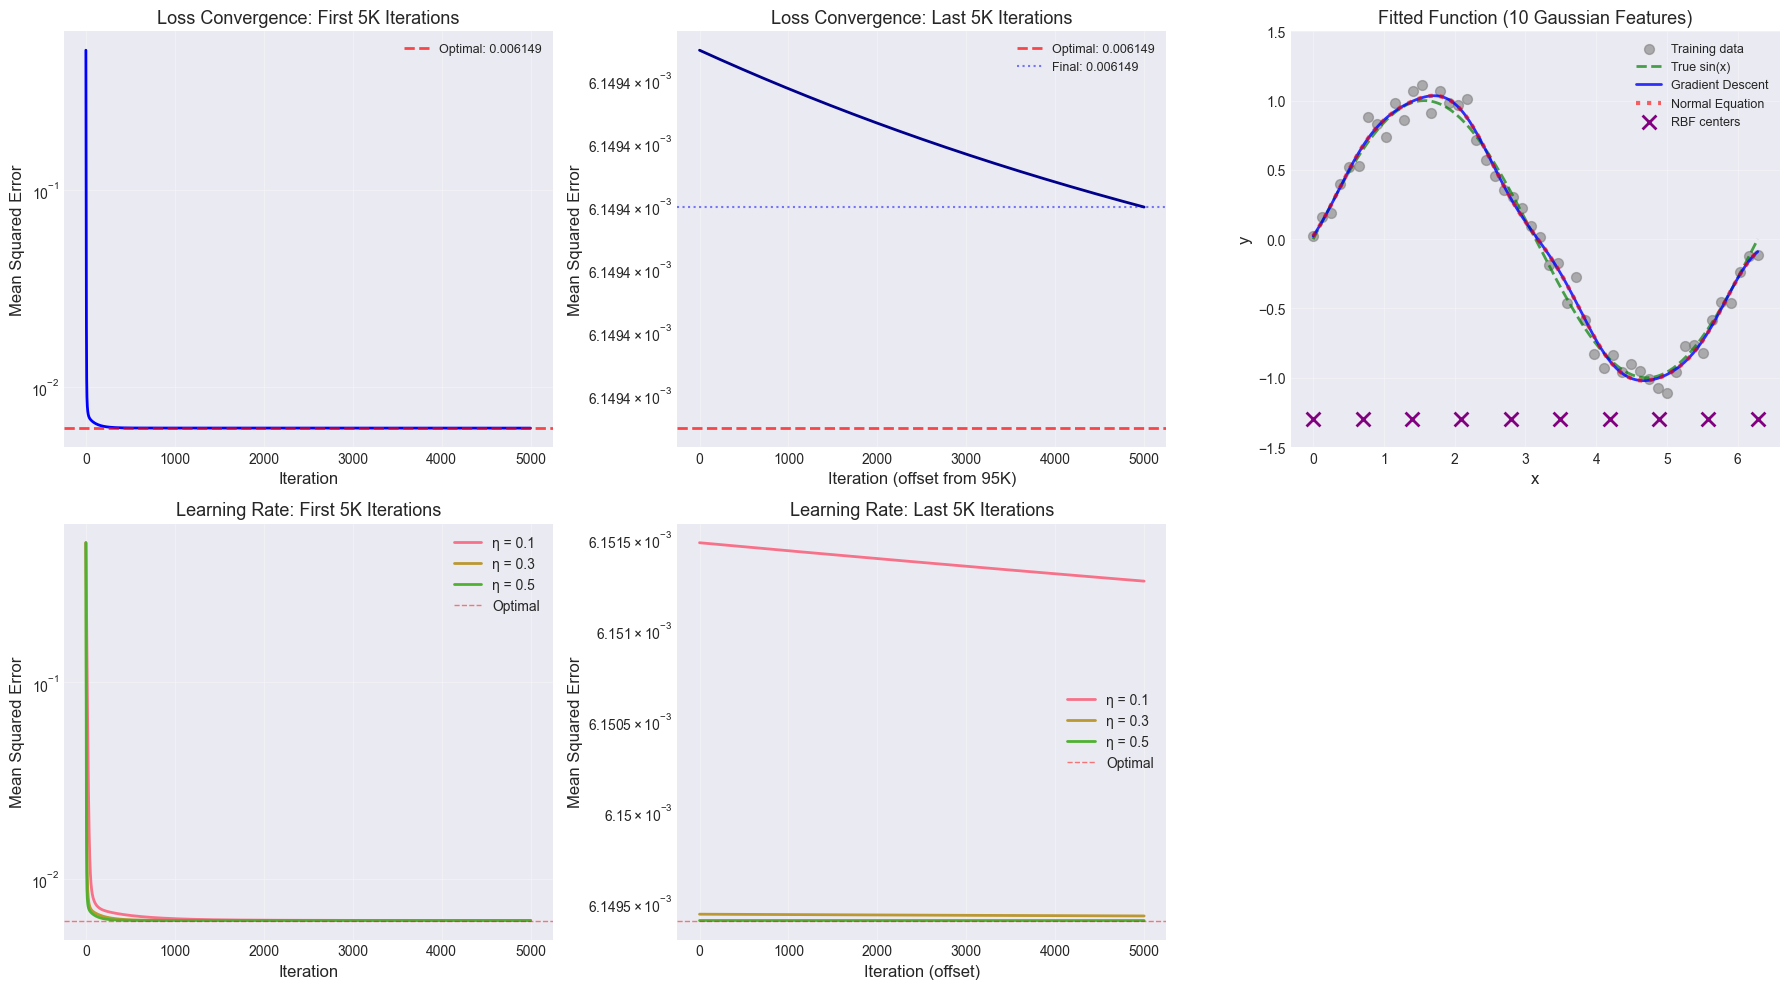

In [22]:
fig = plt.figure(figsize=(18, 10))

# Top Left: First 5K iterations of main convergence
ax1 = plt.subplot(2, 3, 1)
first_5k = loss_history[:5000]
ax1.plot(range(5000), first_5k, linewidth=2, color='blue')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Mean Squared Error', fontsize=12)
ax1.set_title('Loss Convergence: First 5K Iterations', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')  # Log scale to see details
ax1.axhline(y=loss_ne, color='red', linestyle='--', alpha=0.7, linewidth=2,
           label=f'Optimal: {loss_ne:.6f}')
ax1.legend(fontsize=9)

# Top Middle: Last 5K iterations of main convergence
ax2 = plt.subplot(2, 3, 2)
last_5k = loss_history[-5000:]
ax2.plot(range(5000), last_5k, linewidth=2, color='darkblue')
ax2.set_xlabel('Iteration (offset from 95K)', fontsize=12)
ax2.set_ylabel('Mean Squared Error', fontsize=12)
ax2.set_title('Loss Convergence: Last 5K Iterations', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')
ax2.axhline(y=loss_ne, color='red', linestyle='--', alpha=0.7, linewidth=2,
           label=f'Optimal: {loss_ne:.6f}')
ax2.axhline(y=loss_gd, color='blue', linestyle=':', alpha=0.5,
           label=f'Final: {loss_gd:.6f}')
ax2.legend(fontsize=9)

# Top Right: Fitted function comparison
ax3 = plt.subplot(2, 3, 3)

# Create test grid for smooth visualization
X_test_viz = np.linspace(0, 2*np.pi, 200).reshape(-1, 1)
y_test_viz_true = np.sin(X_test_viz).ravel()

# Recompute design matrix with Gaussian features for this test grid
Phi_test_viz = gaussian_features(X_test_viz, centers, sigma)

# Get predictions on this test grid
y_pred_gd = Phi_test_viz @ w_gd
y_pred_ne = Phi_test_viz @ w_ne

ax3.scatter(X_sin, y_sin, alpha=0.6, s=50, label='Training data', color='gray')
ax3.plot(X_test_viz, y_test_viz_true, 'g--', linewidth=2, label='True sin(x)', alpha=0.7)
ax3.plot(X_test_viz, y_pred_gd, 'b-', linewidth=2, label='Gradient Descent', alpha=0.8)
ax3.plot(X_test_viz, y_pred_ne, 'r:', linewidth=3, label='Normal Equation', alpha=0.6)

# Show Gaussian centers
ax3.scatter(centers, np.zeros_like(centers) - 1.3, marker='x', s=100,
           c='purple', label='RBF centers', linewidths=2, zorder=5)

ax3.set_xlabel('x', fontsize=12)
ax3.set_ylabel('y', fontsize=12)
ax3.set_title(f'Fitted Function ({n_centers} Gaussian Features)', fontsize=13)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(-1.5, 1.5)

# Bottom Left: Learning rate sensitivity - First 5K iterations
ax4 = plt.subplot(2, 3, 4)
learning_rates = [0.1, 0.3, 0.5]
# Train with same 100K iterations as main convergence plot
n_iters_lr = 100000
for lr in learning_rates:
    _, loss_hist = gradient_descent_linear_regression(
        Phi_train, y_sin, learning_rate=lr, n_iterations=n_iters_lr, verbose=False
    )
    # Plot only first 5K iterations
    ax4.plot(loss_hist[:5000], label=f'η = {lr}', linewidth=2)

ax4.axhline(y=loss_ne, color='red', linestyle='--', alpha=0.5, linewidth=1, label='Optimal')
ax4.set_xlabel('Iteration', fontsize=12)
ax4.set_ylabel('Mean Squared Error', fontsize=12)
ax4.set_title('Learning Rate: First 5K Iterations', fontsize=13)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_yscale('log')

# Bottom Middle: Learning rate sensitivity - Last 5K iterations
ax5 = plt.subplot(2, 3, 5)
for lr in learning_rates:
    _, loss_hist = gradient_descent_linear_regression(
        Phi_train, y_sin, learning_rate=lr, n_iterations=n_iters_lr, verbose=False
    )
    # Plot only last 5K iterations
    ax5.plot(range(5000), loss_hist[-5000:], label=f'η = {lr}', linewidth=2)

ax5.axhline(y=loss_ne, color='red', linestyle='--', alpha=0.5, linewidth=1, label='Optimal')
ax5.set_xlabel('Iteration (offset)', fontsize=12)
ax5.set_ylabel('Mean Squared Error', fontsize=12)
ax5.set_title('Learning Rate: Last 5K Iterations', fontsize=13)
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)
ax5.set_yscale('log')

plt.tight_layout()
plt.show()